In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RESULTS_DIR = Path("../results/summary")

sns.set_theme(style="whitegrid")

PLOT_DPI = 300

In [2]:
classification_fingerprints_df = pd.read_csv(RESULTS_DIR / "classification_fingerprints.csv")
classification_gnn_df = pd.read_csv(RESULTS_DIR / "classification_gnn.csv")
classification_filtered_gnn_df = pd.read_csv(RESULTS_DIR / "classification_filtered_gnn.csv")

regression_fingerprints_df = pd.read_csv(RESULTS_DIR / "regression_fingerprints.csv")
regression_gnn_df = pd.read_csv(RESULTS_DIR / "regression_gnn.csv")
regression_filtered_gnn_df = pd.read_csv(RESULTS_DIR / "regression_filtered_gnn.csv")


In [3]:
def aggregate_results(df, metrics):

    return (
        df.groupby(
            ["target", "model", "size"]
        )[metrics]
        .mean()
        .reset_index()
    )

In [12]:
classification_metrics = [
    "accuracy",
    "f1",
    "roc_auc",
]

classification_datasets = {
    "Fingerprint": aggregate_results(
        classification_fingerprints_df,
        classification_metrics,
    ),
    "GNN": aggregate_results(
        classification_gnn_df,
        classification_metrics,
    ),
    "Filtered GNN": aggregate_results(
        classification_filtered_gnn_df,
        classification_metrics,
    ),
}

In [8]:
regression_metrics = [
    "rmse",
    "mae",
    "r2",
]

regression_datasets = {
    "Fingerprint": aggregate_results(
        regression_fingerprints_df,
        regression_metrics,
    ),
    "GNN": aggregate_results(
        regression_gnn_df,
        regression_metrics,
    ),
    "Filtered GNN": aggregate_results(
        regression_filtered_gnn_df,
        regression_metrics,
    ),
}

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


def plot_metric_comparison(
    datasets,
    target,
    metric,
):

    fig, axes = plt.subplots(
        1,
        len(datasets),
        figsize=(18, 5),
        sharey=True,
    )

    if len(datasets) == 1:
        axes = [axes]

    for ax, (name, df) in zip(
        axes,
        datasets.items(),
    ):

        subset = (
            df[df["target"] == target]
            .sort_values("size")
        )

        sns.lineplot(
            data=subset,
            x="size",
            y=metric,
            hue="model",
            marker="o",
            ax=ax,
        )

        sizes = sorted(
            subset["size"].unique()
        )

        ax.set_xticks(sizes)

        ax.set_title(name)
        ax.set_xlabel("Size")

        if ax != axes[0]:
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()

    handles, labels = (
        axes[0]
        .get_legend_handles_labels()
    )

    # fig.legend(
    #     handles,
    #     labels,
    #     loc="upper center",
    #     ncol=5,
    # )

    fig.suptitle(
        f"{target} - {metric.upper()}",
        fontsize=16,
    )

    plt.tight_layout()
    plt.show()

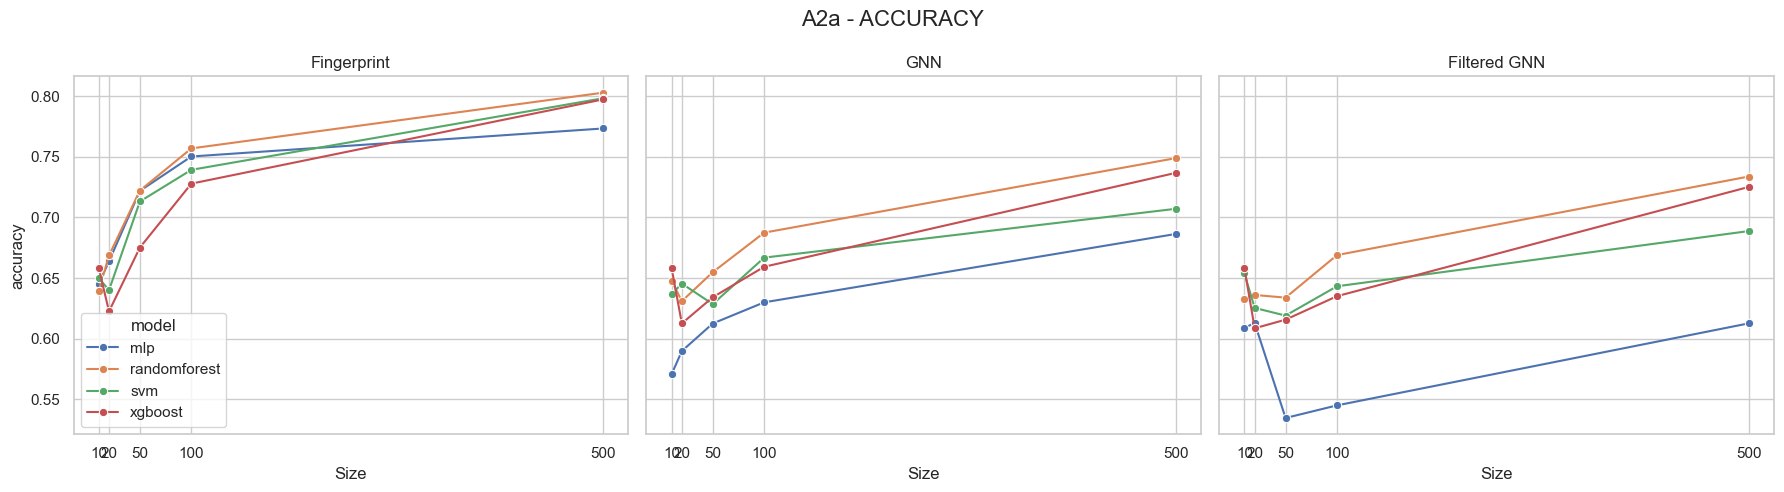

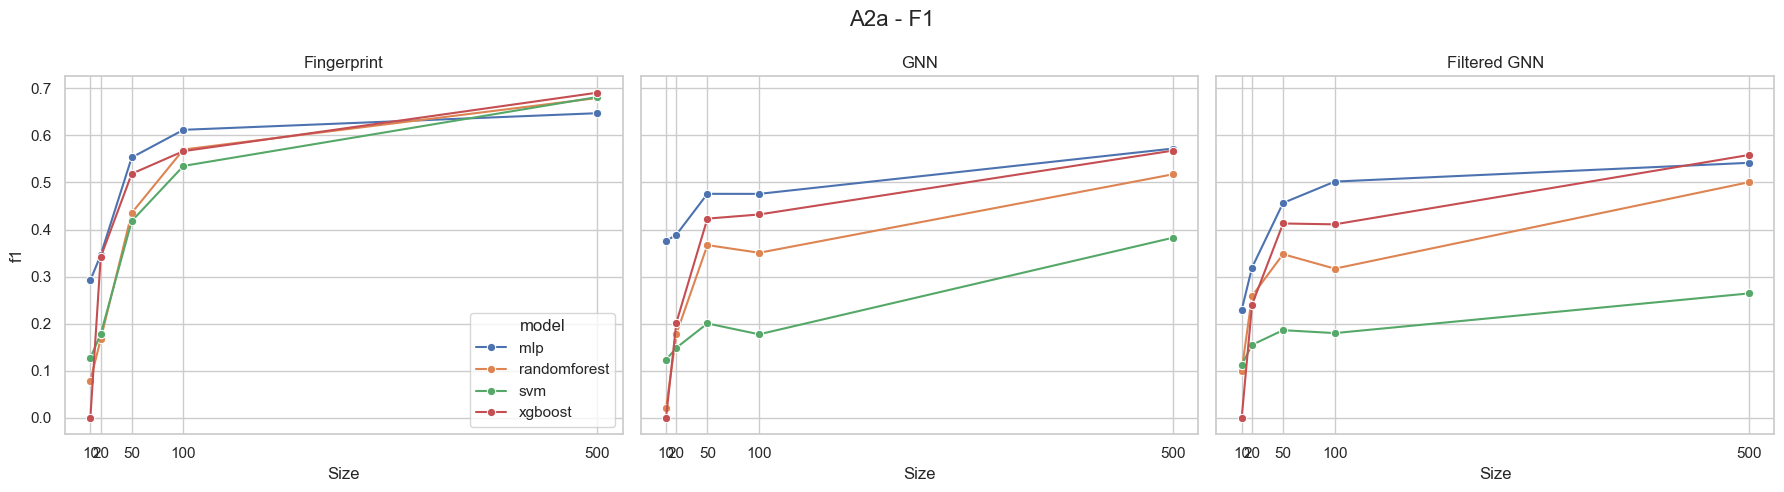

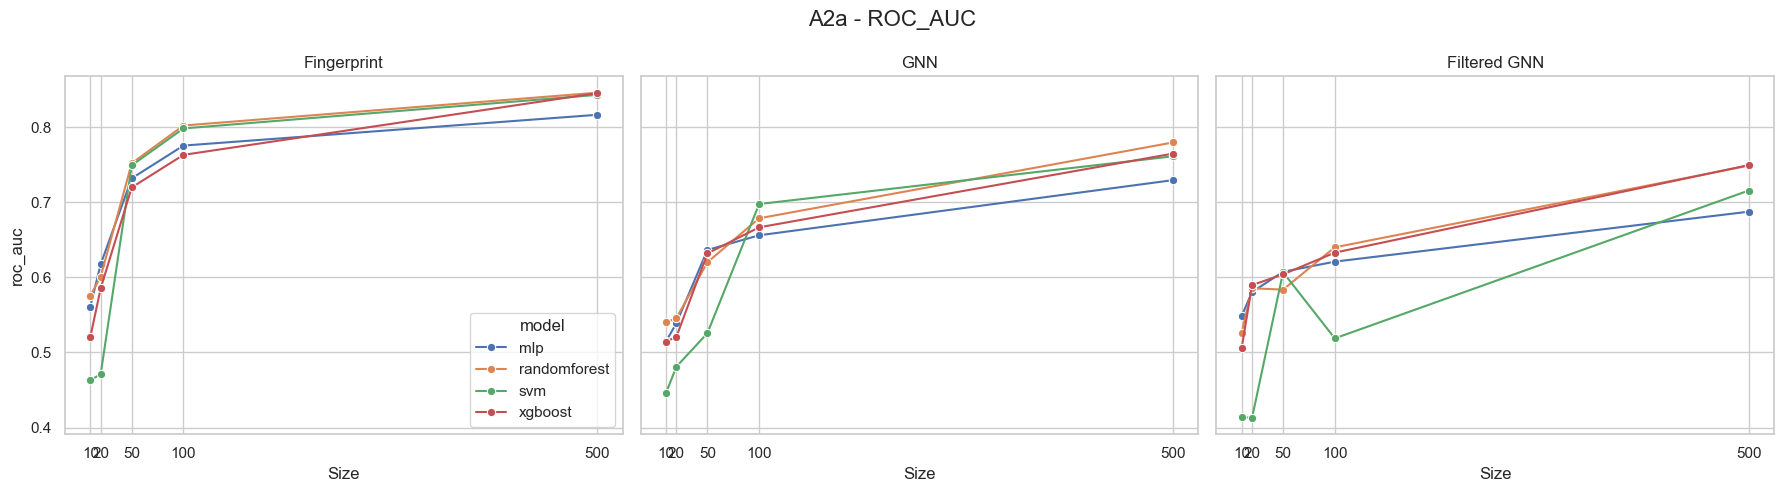

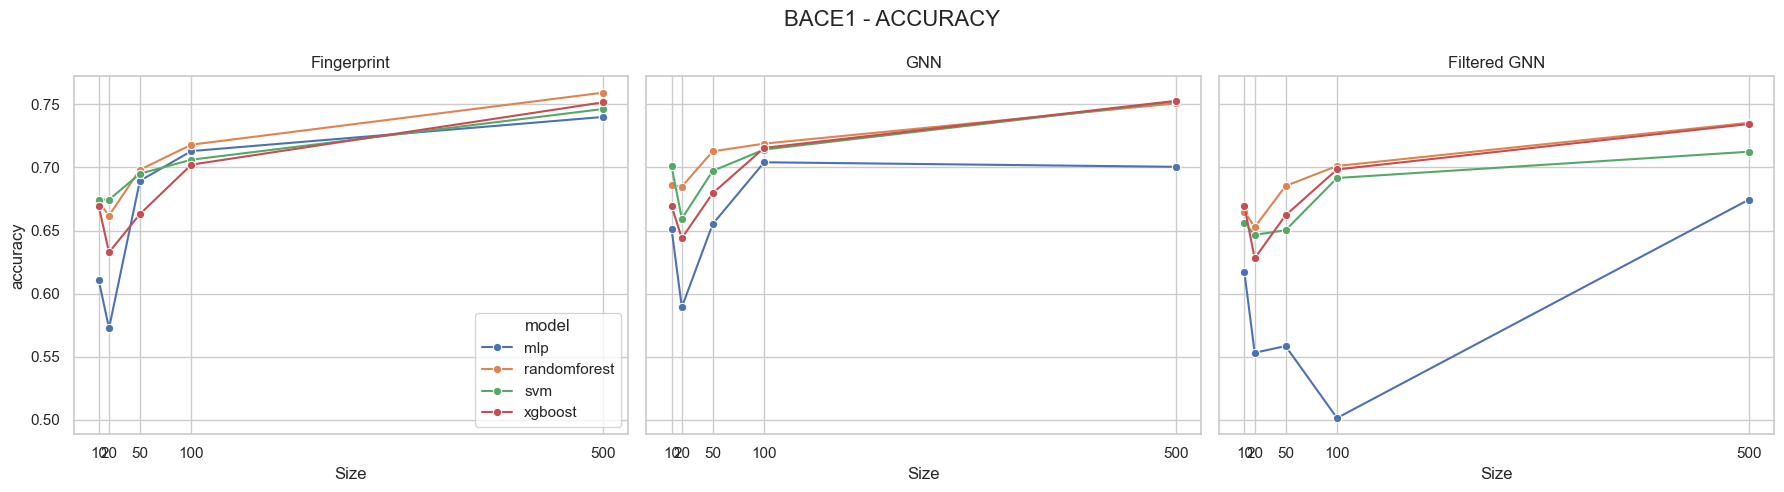

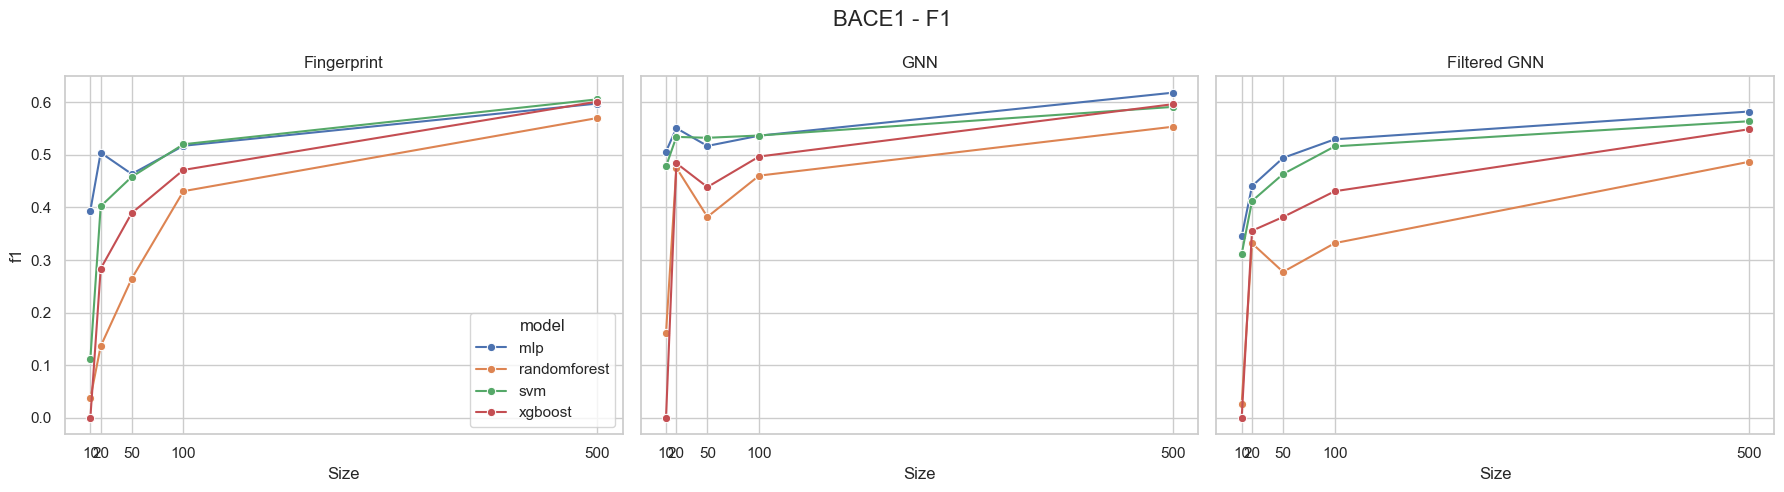

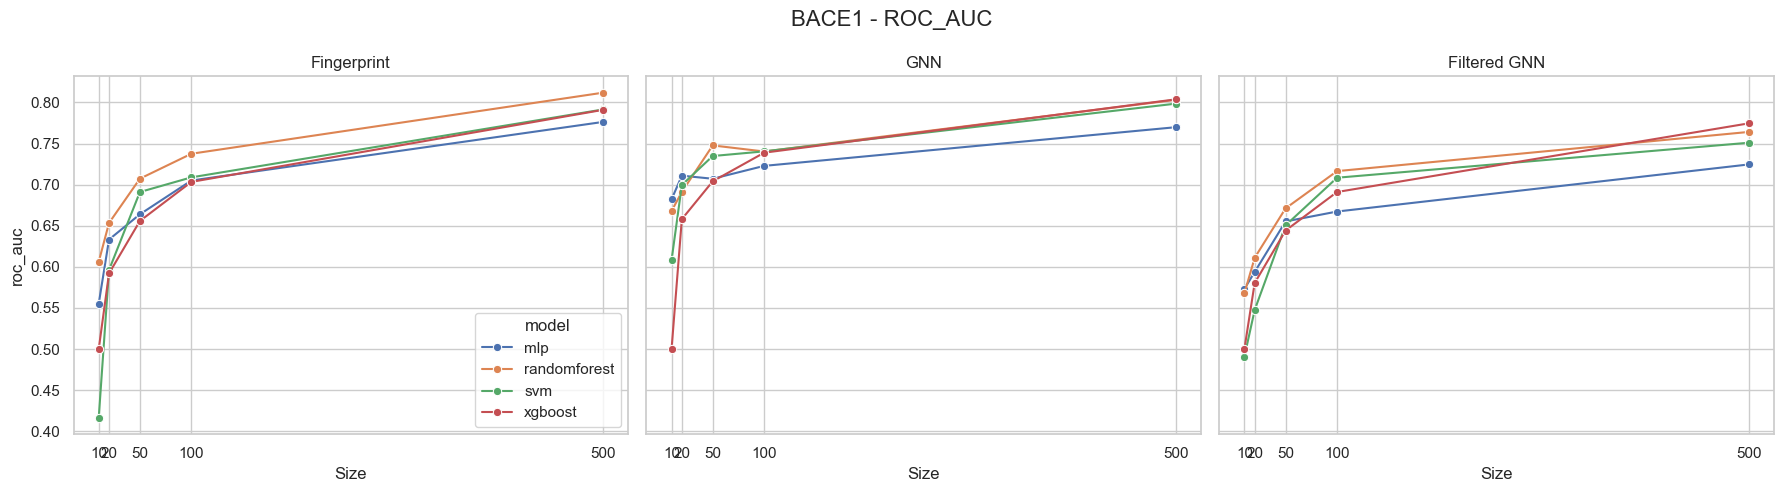

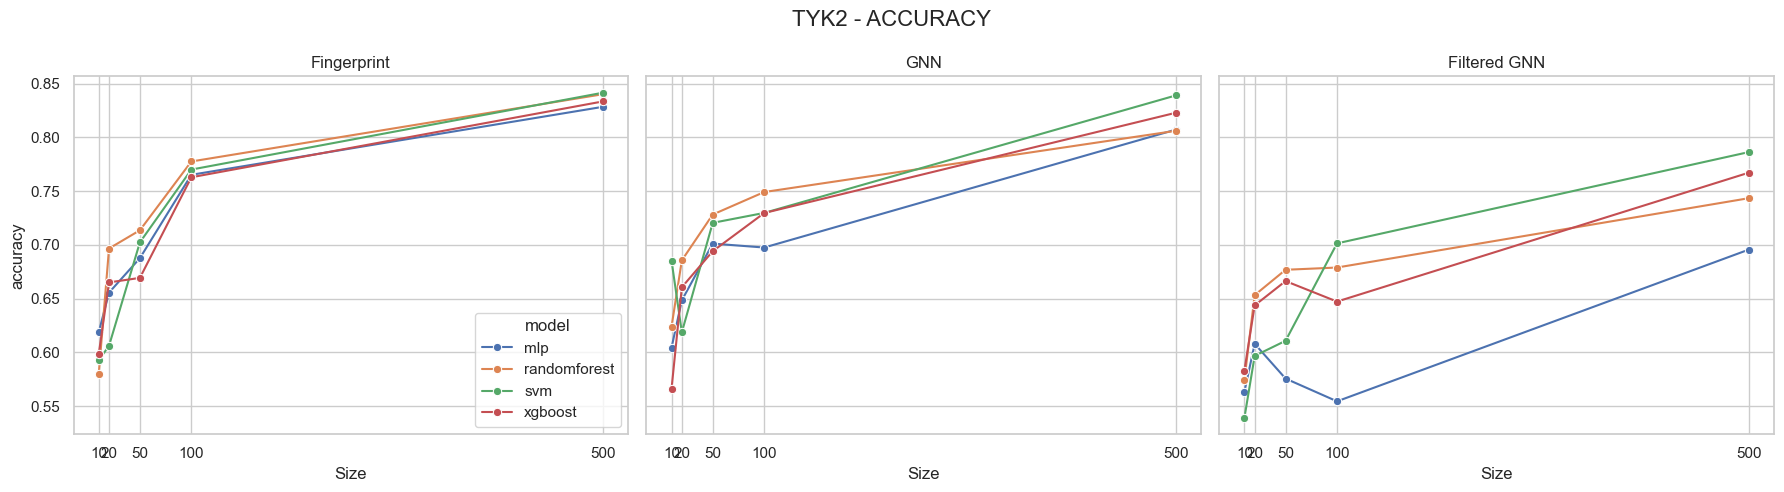

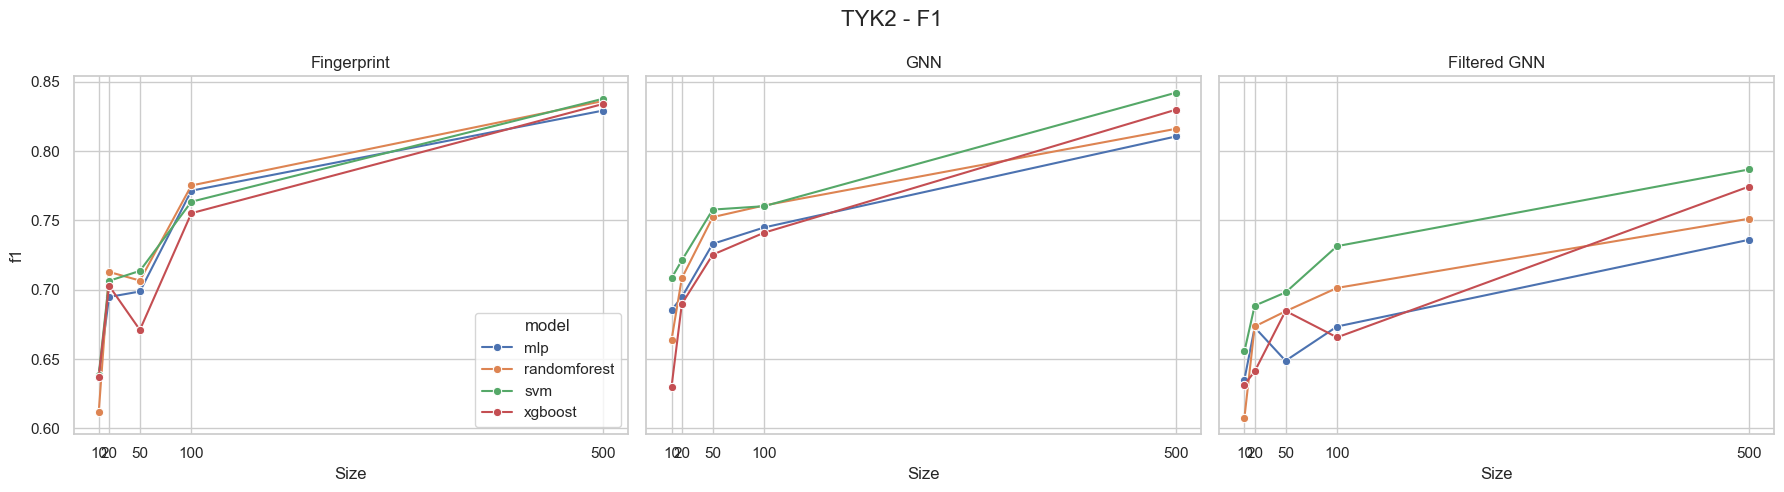

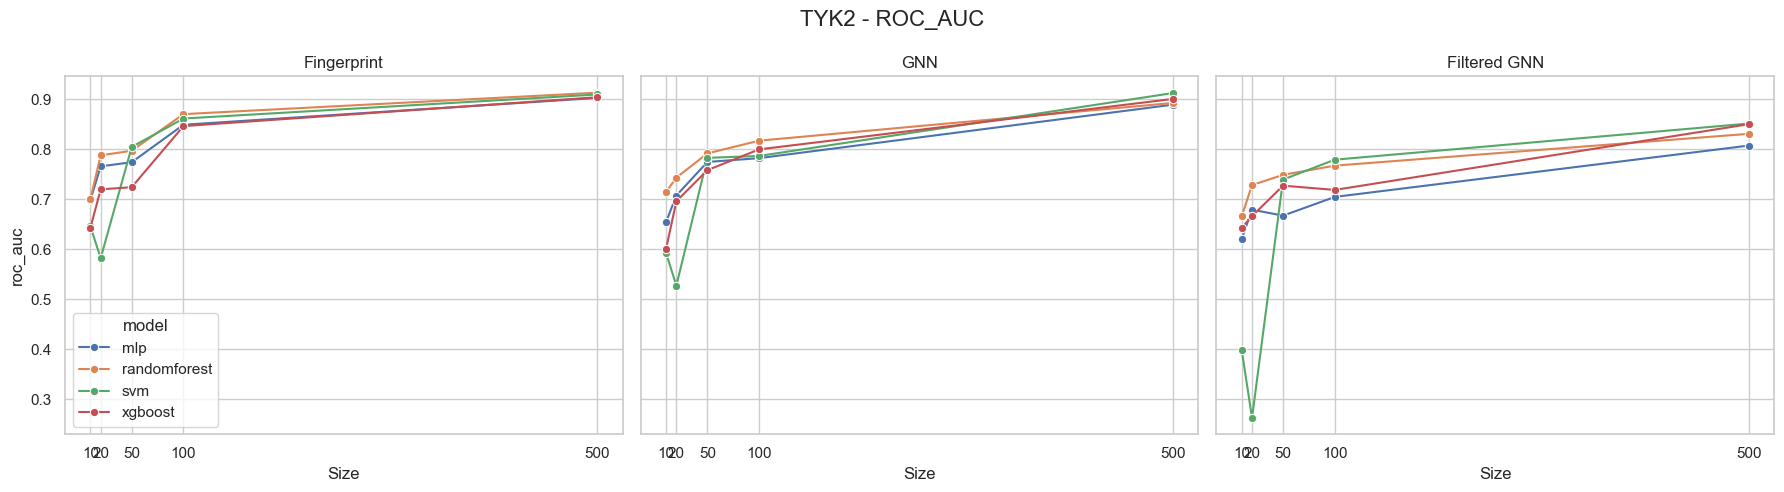

In [17]:
targets = ["A2a", "BACE1", "TYK2"]
for target in targets:
    for metric in classification_metrics:
        plot_metric_comparison(
            classification_datasets,
            target,
            metric,
        )

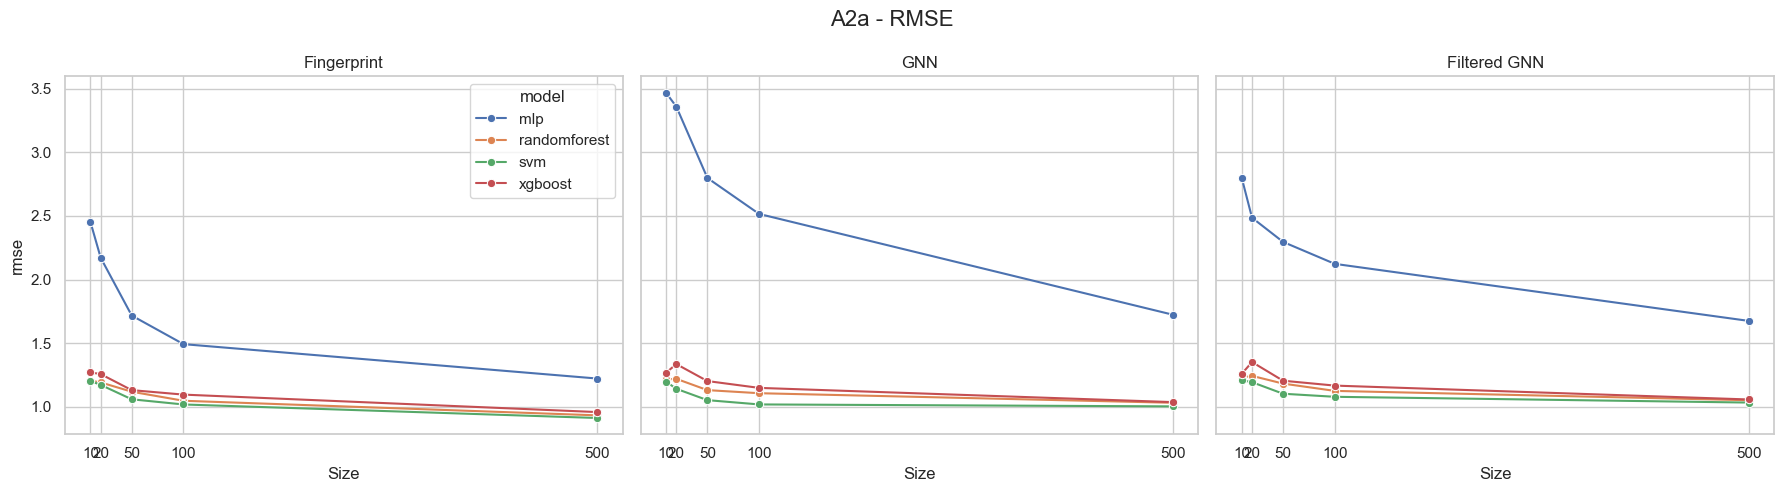

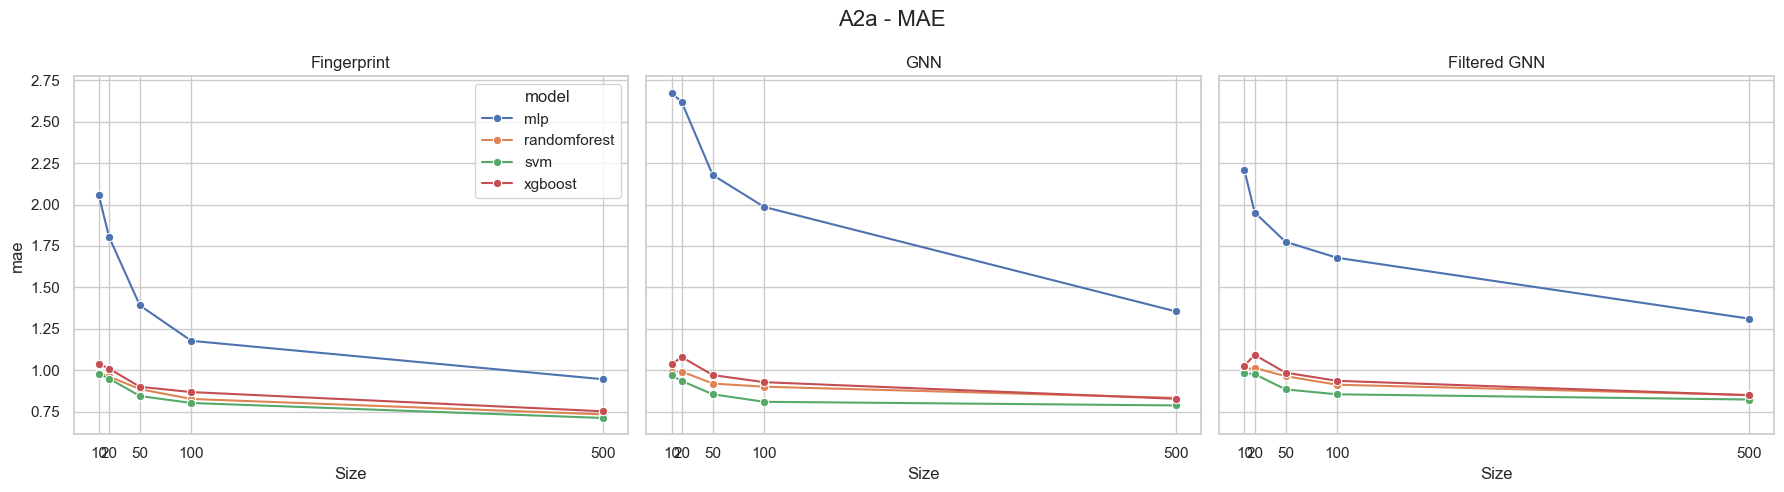

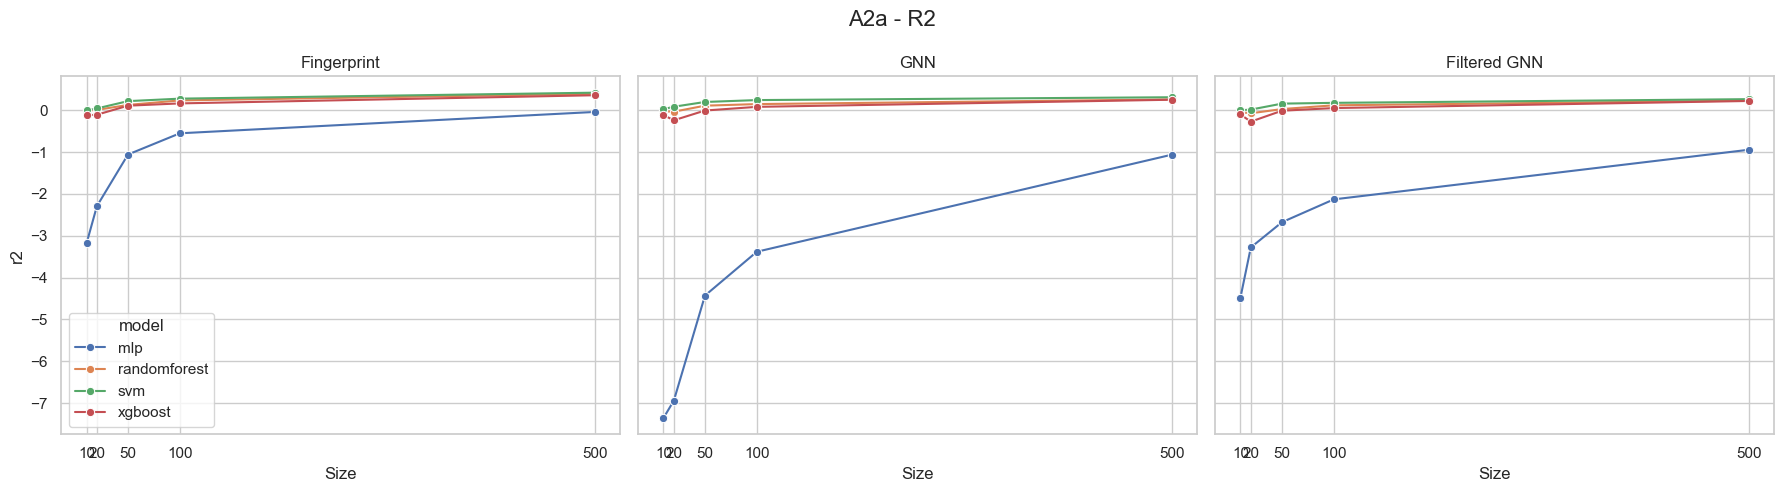

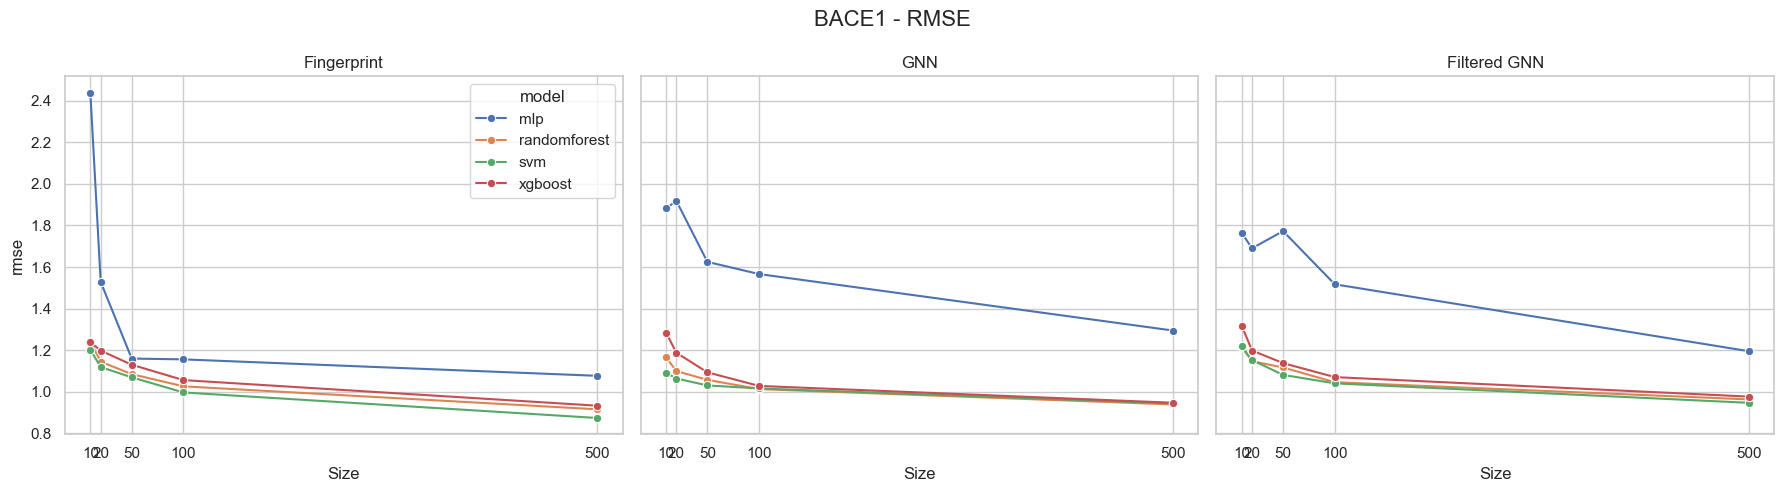

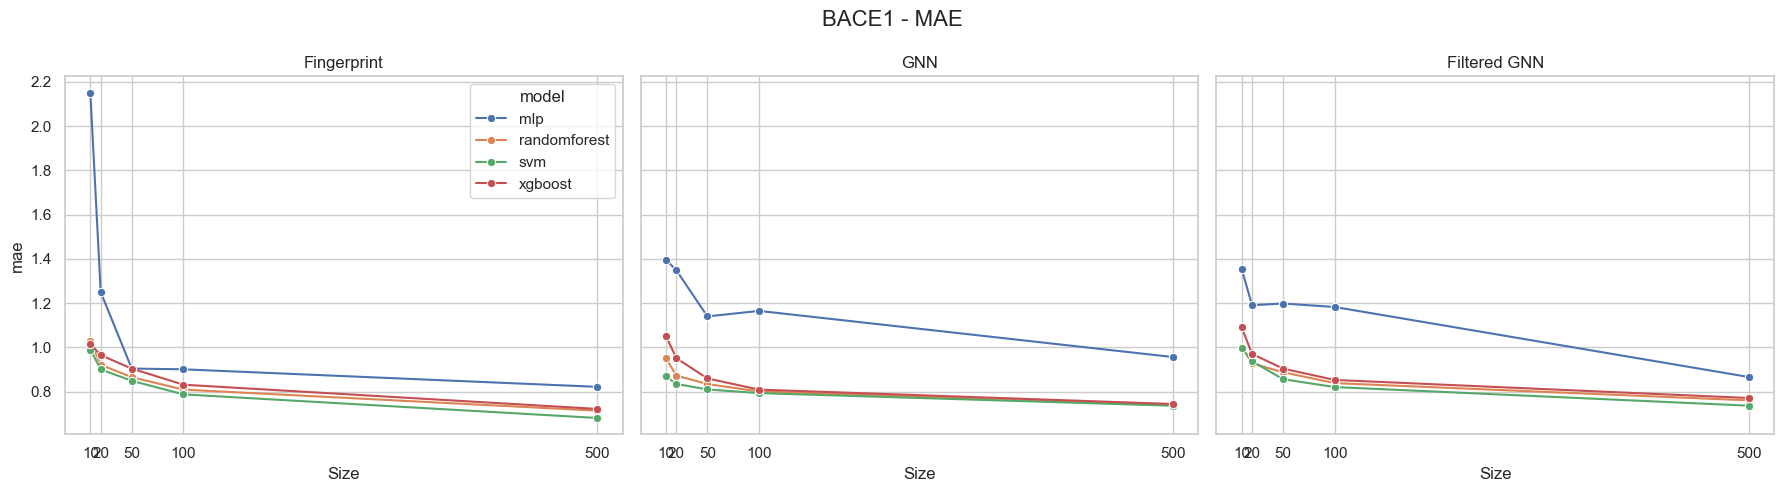

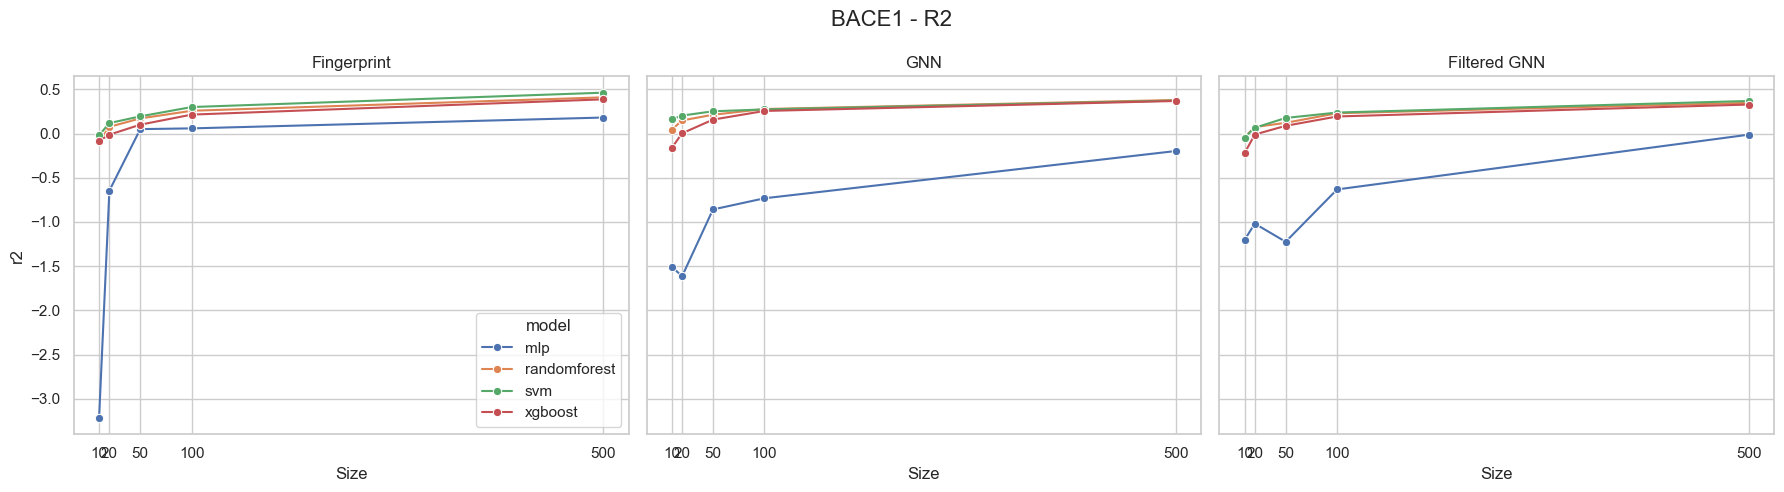

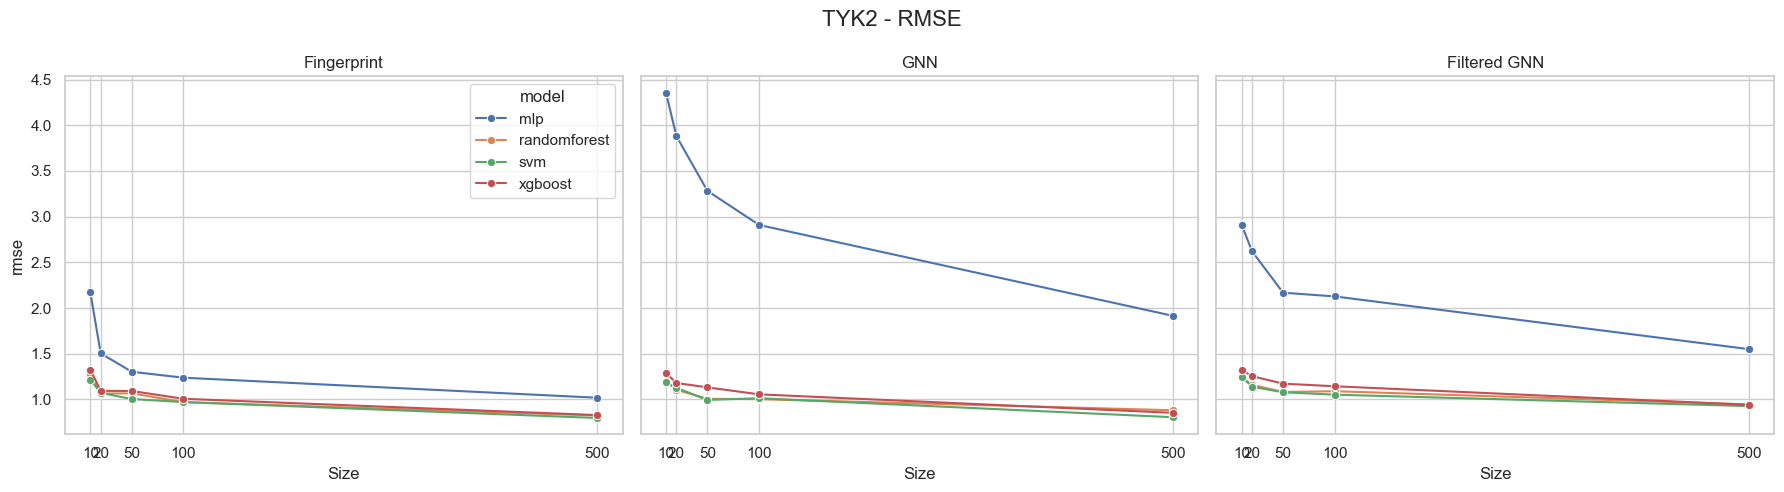

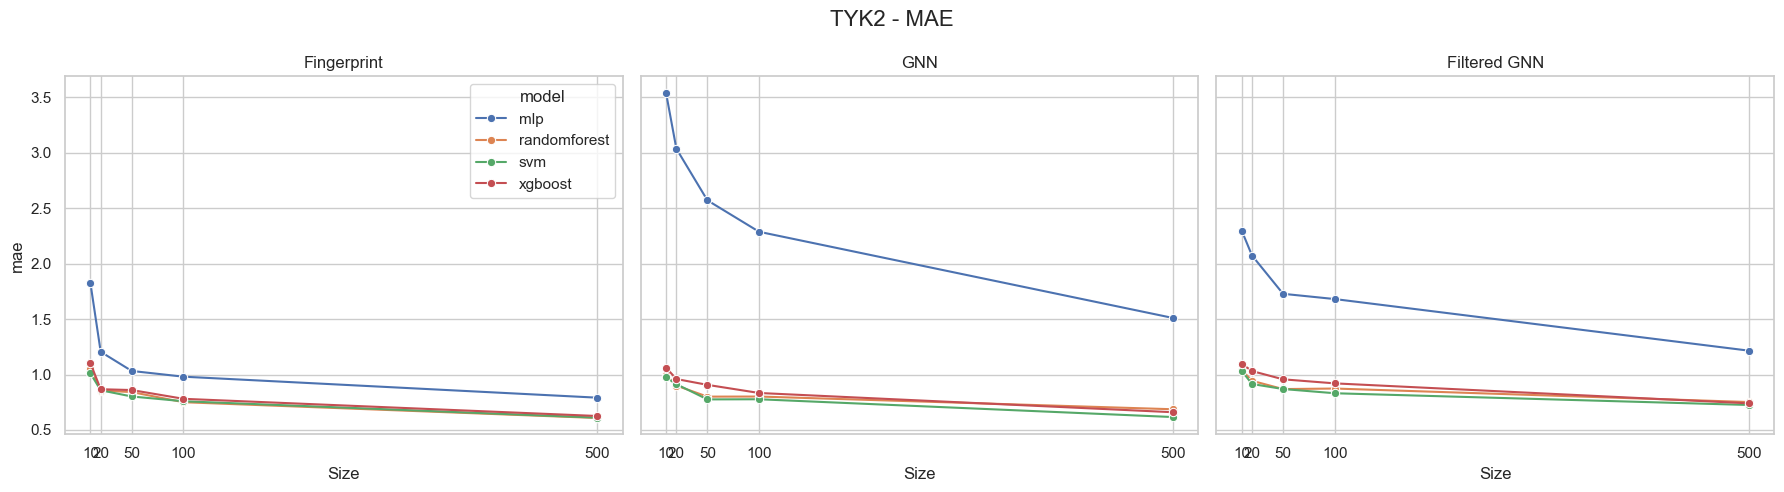

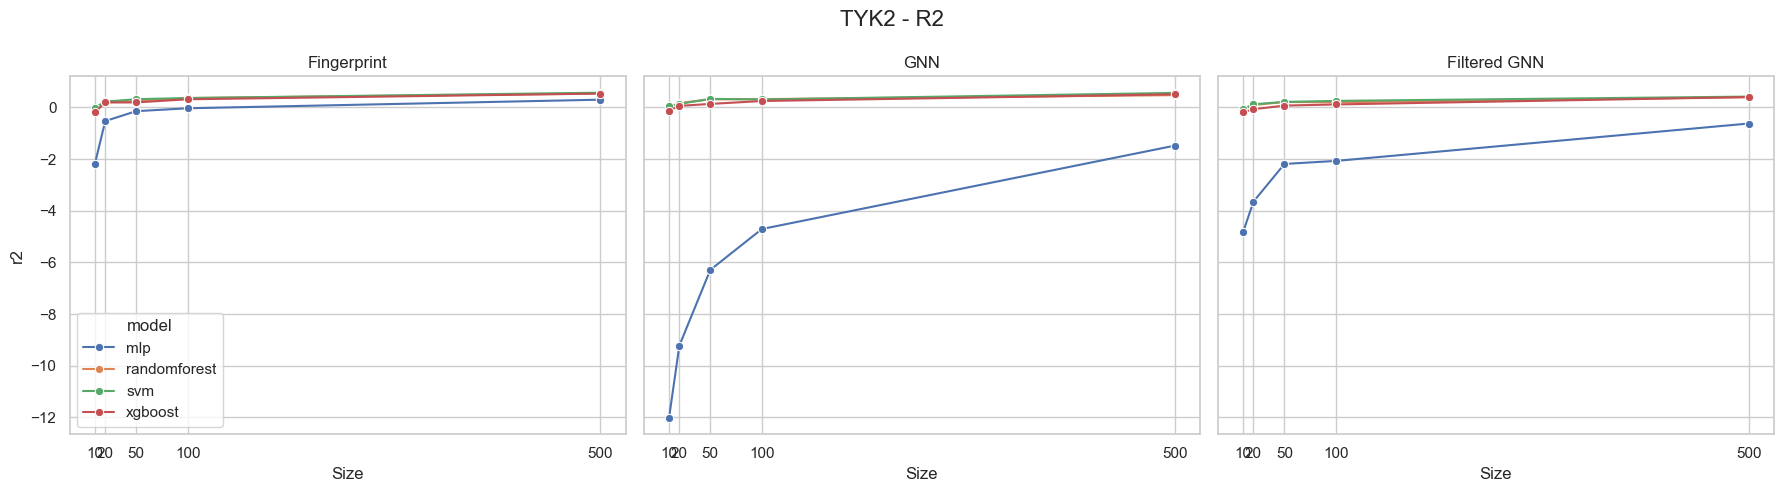

In [18]:
for target in targets:
    for metric in regression_metrics:
        plot_metric_comparison(
            regression_datasets,
            target,
            metric,
        )